# Análise Orçamentária do IFCE – 2017 a 2025

Este notebook consolida e analisa os dados de execução orçamentária do Instituto Federal do Ceará (IFCE) extraídos do Portal da Transparência, integrando‑os com informações de matrículas e deflacionando valores pelo IPCA.

**Etapas do notebook:**

1. **Coleta e preparação** – Leitura dos CSVs anuais do Portal, padronização de colunas, extração do *campus* e união com a base de matrículas.
2. **Análise agregada** – Evolução temporal (nominal vs. real), taxa de execução, composição por grupo de despesa e participação da assistência estudantil.
3. **Análise por campus** – Ranking de execução, orçamento *per capita* e distribuição de matrículas por nível de ensino.

Todas as figuras são salvas em arquivos PNG para referência.

## 1. Coleta e limpeza dos dados

### Portal da Transparência – arquivos anuais

Os arquivos `transparencia_YYYY.csv` (onde YYYY é o ano) devem estar no mesmo diretório do notebook.
Cada arquivo possui o formato padrão do Portal da Transparência (separador `;`).

**Operações realizadas:**
- Leitura de todos os CSVs com reconhecimento automático do ano pelo nome do arquivo.
- Concatenação em um único *DataFrame* (`df_portal`).
- Limpeza dos nomes das colunas: remoção de espaços, acentuação, caracteres especiais e padronização para *snake_case*.
- Criação da coluna `campus` a partir da `unidade_gestora`, utilizando expressão regular e remoção de acentos para normalizar os nomes.

**Colunas numéricas tratadas:**  
`valor_empenhado`, `valor_liquidado`, `valor_pago`, `valor_restos_a_pagar_pagos`, `valor_restos_a_pagar_cancelado` – convertidas para `float` (substituindo `.` e `,` e tratando sinais).

In [1]:
import pandas as pd
import glob
import os
import re
import unicodedata
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

In [43]:
# PORTAL DA TRANSPARÊNCIA — concatena CSVs anuais
# Renomeie seus arquivos como: transparencia_2017.csv, ..., transparencia_2025.csv
# e coloque todos no mesmo diretório do notebook.

arquivos = sorted(glob.glob("transparencia_*.csv"))
print(f"Arquivos encontrados: {len(arquivos)}")

dfs = []
for f in arquivos:
    ano = int(re.search(r'(\d{4})', os.path.basename(f)).group(1))
    df = pd.read_csv(f, sep=";")
    df["ano"] = ano
    dfs.append(df)
    print(f"  {ano}: {df.shape[0]} linhas, {df.shape[1]} colunas")

df_portal = pd.concat(dfs, ignore_index=True)

Arquivos encontrados: 9
  2017: 4817 linhas, 26 colunas
  2018: 5266 linhas, 26 colunas
  2019: 5105 linhas, 26 colunas
  2020: 5364 linhas, 26 colunas
  2021: 4935 linhas, 26 colunas
  2022: 5422 linhas, 26 colunas
  2023: 5086 linhas, 26 colunas
  2024: 6044 linhas, 26 colunas
  2025: 5467 linhas, 26 colunas


In [4]:
# remove coluna fantasma
if "Unnamed: 24" in df_portal.columns:
    df_portal.drop(columns=["Unnamed: 24"], inplace=True)

In [5]:
# limpeza de nomes de coluna
df_portal.columns = (df_portal.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace(r"[()áéíóúâêîôûãõç/]", lambda m: {
        "(":"", ")":"", "á":"a","é":"e","í":"i","ó":"o","ú":"u",
        "â":"a","ê":"e","î":"i","ô":"o","û":"u","ã":"a","õ":"o",
        "ç":"c","/":"_"
    }.get(m.group(), m.group()), regex=True))

print(df_portal.columns.tolist())

['mes_ano', 'orgao_superior_executor', 'orgao_entidade_vinculada_executora', 'unidade_gestora', 'orgao_superior_orcamentario', 'orgao_entidade_orcamentaria', 'unidade_orcamentaria', 'area_de_atuacao_funcao', 'subfuncao', 'programa_orcamentario', 'acao_orcamentaria', 'subtitulo_localizador', 'programa_de_governo', 'autor_emenda', 'plano_orcamentario', 'grupo_de_despesa', 'elemento_de_despesa', 'modalidade_de_despesa', 'categoria_economica', 'valor_empenhado', 'valor_liquidado', 'valor_pago', 'valor_restos_a_pagar_cancelado', 'valor_restos_a_pagar_pagos', 'ano']


### Matrículas – snapshot estático

O arquivo `ifce-matriculas.csv` (separador TAB) contém uma fotografia das matrículas ativas no momento da extração.

**Passos:**
- Normalização dos nomes das colunas e da coluna `campus` (mesma regra usada no Portal, para compatibilidade).
- Filtragem apenas das situações `"Matriculado"` e `"Matriculado(a)"`.
- Agregação por `campus` para obter:
  - `total_alunos`
  - `alunos_presencial`
  - `alunos_ead` (soma de `"EAD"` e `"A distância"`)

O resultado é salvo em `alunos_por_campus.csv`, que será usado nas análises *per capita* e de distribuição.

> **Nota:** O snapshot de matrículas representa um ponto no tempo e pode não coincidir exatamente com o ano fiscal do orçamento. Interpretar o *per capita* com essa ressalva.

In [6]:
# MATRÍCULAS — snapshot estático
df_mat = pd.read_csv(
    "ifce-matriculas.csv",
    sep="\t",
)

df_mat.columns = df_mat.columns.str.strip().str.lower()

In [7]:
def remover_acentos(texto):
    return ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

In [8]:
def extrair_campus(texto):
    if pd.isna(texto): return "NAO IDENTIFICADO"
    partes = str(texto).split(" ", 1)
    nome = partes[1] if len(partes) > 1 else partes[0]
    nome = nome.replace("/IFCE", "").replace("IFCE/", "").strip()
    # remove hífen inicial que vem do Portal ("- CAMPUS X")
    nome = re.sub(r"^-\s*", "", nome).strip()
    # remove acentos para padronizar
    nome = remover_acentos(nome.upper())
    return nome

In [9]:
df_portal["campus"] = df_portal["unidade_gestora"].apply(extrair_campus)

In [10]:
# Mesma normalização nas matrículas — aplicada UMA vez, com remoção de acentos
df_mat["campus"] = (df_mat["desc_instituicao"]
    .str.upper()
    .str.replace("IFCE - ", "", regex=False)
    .str.strip()
    .apply(remover_acentos))

In [12]:
# Verifica resultado
print("Orçamento:", sorted(df_portal["campus"].unique()))
print("Matrículas:", sorted(df_mat["campus"].unique()))

Orçamento: ['CAMPUS ACARAU', 'CAMPUS ACOPIARA', 'CAMPUS ARACATI', 'CAMPUS BATURITE', 'CAMPUS BOA VIAGEM', 'CAMPUS CAMOCIM', 'CAMPUS CANINDE', 'CAMPUS CAUCAIA', 'CAMPUS CEDRO', 'CAMPUS CRATEUS', 'CAMPUS CRATO', 'CAMPUS FORTALEZA', 'CAMPUS HORIZONTE', 'CAMPUS IGUATU', 'CAMPUS ITAPIPOCA', 'CAMPUS JAGUARIBE', 'CAMPUS JUAZEIRO DO NORTE', 'CAMPUS LIMOEIRO DO NORTE', 'CAMPUS MARACANAU', 'CAMPUS MARANGUAPE', 'CAMPUS MORADA NOVA', 'CAMPUS PARACURU', 'CAMPUS PECEM', 'CAMPUS QUIXADA', 'CAMPUS SOBRAL', 'CAMPUS TABULEIRO DO NORTE', 'CAMPUS TAUA', 'CAMPUS TIANGUA', 'CAMPUS UBAJARA', 'CAMPUS UMIRIM', 'INST.FED.DE EDUC.,CIENC.E TEC.DO CEARA', 'POLO DE INOVACAO FORTALEZA']
Matrículas: ['CAMPUS ACARAU', 'CAMPUS ACOPIARA', 'CAMPUS ARACATI', 'CAMPUS BATURITE', 'CAMPUS BOA VIAGEM', 'CAMPUS CAMOCIM', 'CAMPUS CANINDE', 'CAMPUS CAUCAIA', 'CAMPUS CEDRO', 'CAMPUS CRATEUS', 'CAMPUS CRATO', 'CAMPUS FORTALEZA', 'CAMPUS GUARAMIRANGA', 'CAMPUS HORIZONTE', 'CAMPUS IGUATU', 'CAMPUS ITAPIPOCA', 'CAMPUS JAGUARIBE', 'CAM

In [13]:
# converte valores monetários
colunas_valor = ["valor_empenhado", "valor_liquidado", "valor_pago",
                 "valor_restos_a_pagar_pagos", "valor_restos_a_pagar_cancelado"]
for col in colunas_valor:
    if col in df_portal.columns:
        if df_portal[col].dtype == object:
            df_portal[col] = (df_portal[col].astype(str)
                .str.replace(".", "", regex=False)
                .str.replace(",", ".", regex=False)
                .str.replace("- ", "-", regex=False)
                .str.strip()
                .replace("", "0")
                .astype(float))
        df_portal[col] = df_portal[col].fillna(0)

**Flag de assistência estudantil:**  
Criação da coluna `is_assist_estudantil = True` quando a ação orçamentária contém `"2994"` ou a palavra `"assistenc"` (case‑insensitive).

O resultado é salvo em `portal_transparencia_clean.parquet` para uso nas etapas seguintes.

In [16]:
# flag assistência estudantil (ação 2994 ou nome contendo "assistencia")
df_portal["is_assist_estudantil"] = (
    df_portal["acao_orcamentaria"].astype(str).str.contains("2994", na=False) |
    df_portal["acao_orcamentaria"].astype(str).str.lower().str.contains("assistenc", na=False)
)

print(f"\nTotal de linhas: {len(df_portal):,}")
print(f"Anos cobertos: {sorted(df_portal['ano'].unique())}")
print(f"Campi identificados ({df_portal['campus'].nunique()}):")
print(df_portal['campus'].value_counts().to_string())
print(f"\nLinhas de assistência estudantil: {df_portal['is_assist_estudantil'].sum():,}")

df_portal.to_parquet("portal_transparencia_clean.parquet", index=False)
print("\nSalvo: portal_transparencia_clean.parquet")


Total de linhas: 47,506
Anos cobertos: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Campi identificados (32):
campus
INST.FED.DE EDUC.,CIENC.E TEC.DO CEARA    6959
CAMPUS FORTALEZA                          2592
CAMPUS MARACANAU                          1857
CAMPUS JUAZEIRO DO NORTE                  1791
CAMPUS CAUCAIA                            1736
CAMPUS CRATEUS                            1627
CAMPUS SOBRAL                             1587
CAMPUS LIMOEIRO DO NORTE                  1543
CAMPUS IGUATU                             1494
CAMPUS TABULEIRO DO NORTE                 1488
CAMPUS CRATO                              1475
CAMPUS TIANGUA                            1398
CAMPUS CANINDE                            1396
CAMPUS JAGUARIBE                          1391
CAMPUS ARACATI                            1390
CAMPUS QUIXADA                            1389
CAMPUS TAUA                   

In [17]:
# filtra só matrículas ativas
situacoes_ativas = ["Matriculado", "Matriculado(a)"]
df_ativos = df_mat[df_mat["sit_matricula"].isin(situacoes_ativas)].copy()

print(f"\nTotal de matrículas: {len(df_mat):,}")
print(f"Matrículas ativas: {len(df_ativos):,}")
print(f"\nCampi no arquivo de matrículas:")
print(df_ativos["campus"].value_counts().to_string())


Total de matrículas: 340,235
Matrículas ativas: 41,360

Campi no arquivo de matrículas:
campus
CAMPUS FORTALEZA             9377
CAMPUS MARACANAU             3366
CAMPUS JUAZEIRO DO NORTE     2482
CAMPUS CAUCAIA               2064
CAMPUS LIMOEIRO DO NORTE     1734
CAMPUS SOBRAL                1715
CAMPUS IGUATU                1588
CAMPUS QUIXADA               1563
CAMPUS CRATEUS               1471
CAMPUS CEDRO                 1448
CAMPUS CRATO                 1427
CAMPUS ACARAU                1080
CAMPUS PARACURU              1072
CAMPUS BOA VIAGEM            1060
CAMPUS ARACATI                997
CAMPUS BATURITE               923
CAMPUS TIANGUA                905
CAMPUS UMIRIM                 829
CAMPUS CAMOCIM                820
CAMPUS PECEM                  800
CAMPUS JAGUARIBE              731
CAMPUS TAUA                   676
CAMPUS TABULEIRO DO NORTE     658
CAMPUS CANINDE                641
CAMPUS ITAPIPOCA              606
CAMPUS UBAJARA                312
CAMPUS HORIZONTE    

In [19]:
# contagem de alunos ativos por campus
df_alunos_campus = (df_ativos
    .groupby("campus")
    .agg(
        total_alunos=("cod_matricula", "count"),
        alunos_presencial=("modalidade_ensino", lambda x: (x=="Presencial").sum()),
        alunos_ead=("modalidade_ensino", lambda x: (x=="EAD").sum() + (x=="A distância").sum()),
    )
    .reset_index()
)

df_alunos_campus.to_csv("alunos_por_campus.csv", index=False)
print("\nSalvo: alunos_por_campus.csv")
print(df_alunos_campus.to_string())


Salvo: alunos_por_campus.csv
                       campus  total_alunos  alunos_presencial  alunos_ead
0               CAMPUS ACARAU          1080               1062           0
1             CAMPUS ACOPIARA           172                172           0
2              CAMPUS ARACATI           997                997           0
3             CAMPUS BATURITE           923                649           0
4           CAMPUS BOA VIAGEM          1060                917           0
5              CAMPUS CAMOCIM           820                820           0
6              CAMPUS CANINDE           641                641           0
7              CAMPUS CAUCAIA          2064               1033           0
8                CAMPUS CEDRO          1448               1389           0
9              CAMPUS CRATEUS          1471               1471           0
10               CAMPUS CRATO          1427               1404           0
11           CAMPUS FORTALEZA          9377               8945        

### 0.3 IPCA – deflator base 2017

Para comparar valores nominais ao longo do tempo, utilizamos o IPCA acumulado (IBGE) com base fixa em 2017 = 1,000.

**Fatores utilizados:**

| Ano | IPCA acumulado |
|-----|----------------|
| 2017 | 1,000 |
| 2018 | 1,037 |
| 2019 | 1,058 |
| 2020 | 1,102 |
| 2021 | 1,202 |
| 2022 | 1,338 |
| 2023 | 1,396 |
| 2024 | 1,470 |
| 2025 | 1,530 |

O arquivo `ipca_base2017.csv` é gerado para ser reutilizado nas etapas de análise.

In [23]:
# Índice acumulado base 2017 = 1.00 (IBGE)
ipca = {
    2017: 1.000, 2018: 1.037, 2019: 1.058, 2020: 1.102,
    2021: 1.202, 2022: 1.338, 2023: 1.396, 2024: 1.470, 2025: 1.530
}
df_ipca = pd.DataFrame(list(ipca.items()), columns=["ano", "ipca_acum"])
df_ipca.to_csv("ipca_base2017.csv", index=False)
print("\nSalvo: ipca_base2017.csv")

df_ipca


Salvo: ipca_base2017.csv


,ano,ipca_acum
0,2017,1.000
1,2018,1.037
2,2019,1.058
3,2020,1.102
4,2021,1.202
5,2022,1.338
6,2023,1.396
7,2024,1.470
8,2025,1.530


## 1. Análise Orçamentária Agregada

Com os dados limpos, partimos para a consolidação anual e geração das primeiras visualizações.

**Principais agregações:**
- Totais anuais de empenhado, liquidado e pago.
- Cálculo da **taxa de execução** = `pago / empenhado`.
- Valores reais (deflacionados) para o empenhado.
- Composição por grupo de despesa (Pessoal, Outras Despesas Correntes, Investimentos, Inversões Financeiras).
- Valores e percentual da assistência estudantil.

As figuras a seguir apresentam os resultados.

In [25]:
df = pd.read_parquet("portal_transparencia_clean.parquet")
ipca = pd.read_csv("ipca_base2017.csv")

In [26]:
# agregações anuais
anual = (df.groupby("ano")
    .agg(empenhado=("valor_empenhado","sum"),
         liquidado=("valor_liquidado","sum"),
         pago=("valor_pago","sum"))
    .reset_index()
    .merge(ipca, on="ano"))

anual["emp_real"] = anual["empenhado"] / anual["ipca_acum"]
anual["tx_exec"]  = anual["pago"] / anual["empenhado"] * 100
anual["residuo"]  = anual["empenhado"] - anual["pago"]

In [27]:
# composição por grupo de despesa
grupos = (df.groupby(["ano", "grupo_de_despesa"])
    ["valor_pago"].sum()
    .reset_index()
    .pivot(index="ano", columns="grupo_de_despesa", values="valor_pago")
    .fillna(0))

In [28]:
# assistência estudantil
assist = (df[df["is_assist_estudantil"]]
    .groupby("ano")
    .agg(assist_emp=("valor_empenhado","sum"),
         assist_pago=("valor_pago","sum"))
    .reset_index()
    .merge(anual[["ano","empenhado"]], on="ano"))
assist["pct_assist"] = assist["assist_emp"] / assist["empenhado"] * 100

### Figura 1 – Evolução nominal vs. real e taxa de execução

**Painel esquerdo:**  
Evolução dos valores empenhados e pagos (em R$ milhões) – tanto nominais quanto reais (base 2017). Permite visualizar o crescimento real do orçamento, descontada a inflação.

**Painel direito:**  
Taxa de execução por ano (pago/empenhado). A linha tracejada indica a média do período. Cores:
- Verde: execução ≥ 90%
- Azul: execução entre 85% e 90%
- Vermelho: execução < 85%

*Arquivo salvo: `fig1_evolucao.png`*

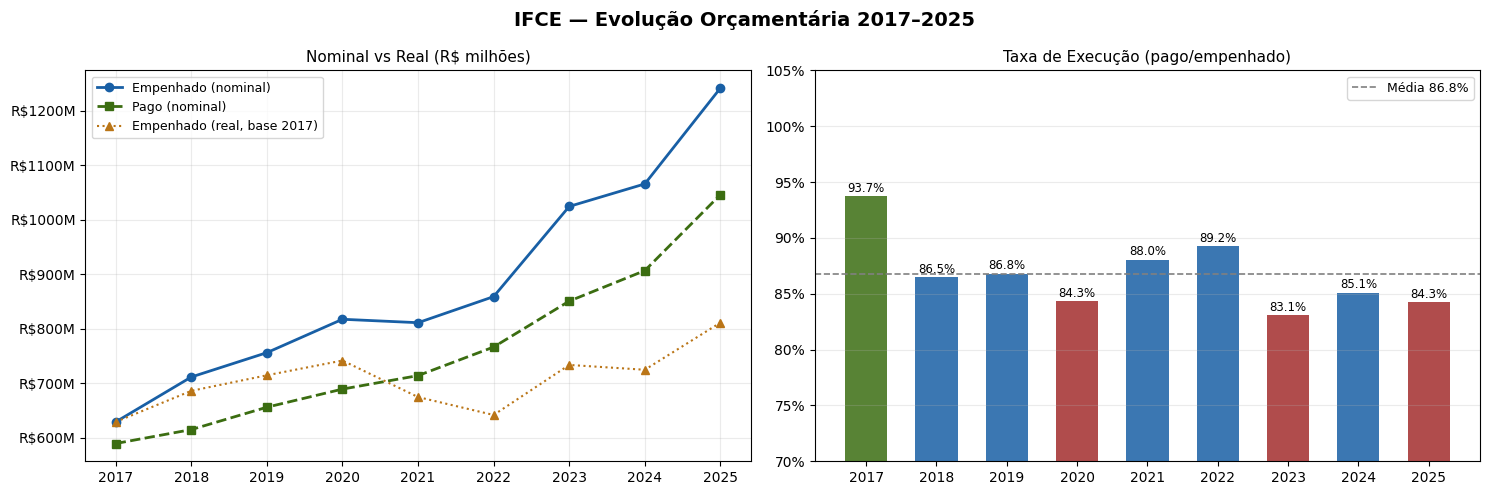

In [29]:
# FIGURA 1 — Evolução + deflação
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("IFCE — Evolução Orçamentária 2017–2025", fontsize=14, fontweight="bold")

ax = axes[0]
ax.plot(anual["ano"], anual["empenhado"]/1e6, "o-", color="#185FA5", lw=2, label="Empenhado (nominal)")
ax.plot(anual["ano"], anual["pago"]/1e6,      "s--", color="#3B6D11", lw=2, label="Pago (nominal)")
ax.plot(anual["ano"], anual["emp_real"]/1e6,  "^:", color="#BA7517", lw=1.5, label="Empenhado (real, base 2017)")
ax.set_title("Nominal vs Real (R$ milhões)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"R${x:.0f}M"))
ax.set_xticks(anual["ano"]); ax.legend(fontsize=9); ax.grid(alpha=0.25)

ax = axes[1]
colors_tx = ["#3B6D11" if t >= 90 else "#185FA5" if t >= 85 else "#A32D2D"
             for t in anual["tx_exec"]]
bars = ax.bar(anual["ano"], anual["tx_exec"], color=colors_tx, alpha=0.85, width=0.6)
ax.axhline(anual["tx_exec"].mean(), color="gray", lw=1.2, linestyle="--",
           label=f"Média {anual['tx_exec'].mean():.1f}%")
for bar, v in zip(bars, anual["tx_exec"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f"{v:.1f}%", ha="center", fontsize=8.5)
ax.set_title("Taxa de Execução (pago/empenhado)", fontsize=11)
ax.set_ylim(70, 105); ax.set_xticks(anual["ano"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}%"))
ax.legend(fontsize=9); ax.grid(alpha=0.25, axis="y")

plt.tight_layout()
plt.savefig("fig1_evolucao.png", dpi=150, bbox_inches="tight")
plt.show()

### Figura 2 – Composição do orçamento por grupo de despesa

Gráfico de barras empilhadas mostrando a evolução da distribuição do **valor pago** entre os quatro principais grupos de despesa.

Cores:
- **Azul** – Pessoal e Encargos Sociais
- **Laranja** – Outras Despesas Correntes
- **Verde** – Investimentos
- **Vermelho** – Inversões Financeiras

Observa‑se a predominância do grupo de pessoal ao longo de todo o período, representando consistentemente mais de 70% do total pago.

*Arquivo salvo: `fig2_grupos_despesa.png`*

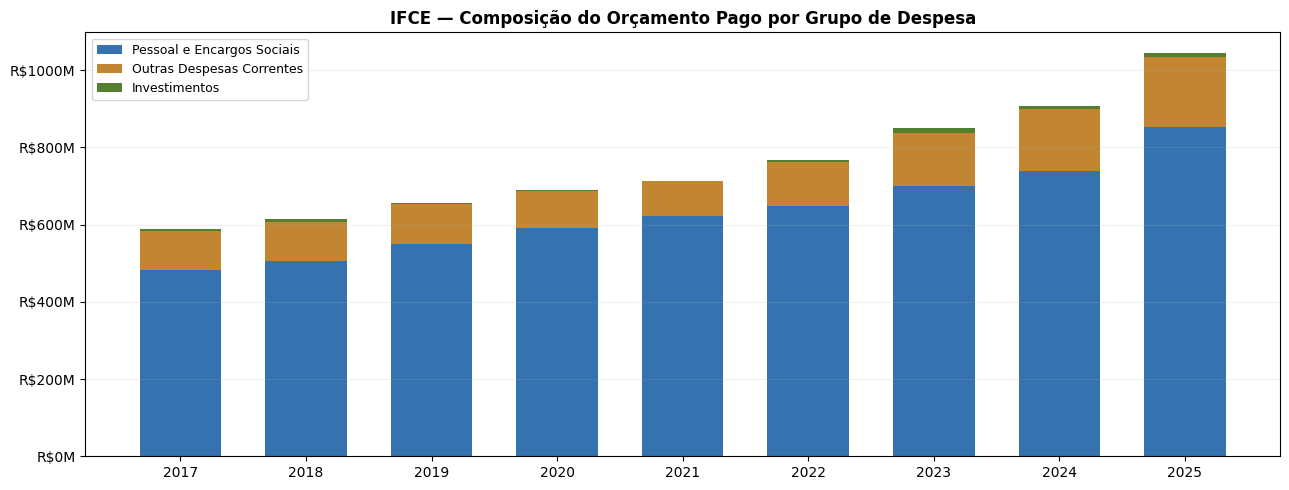

In [30]:
# FIGURA 2 — Composição por grupo de despesa
fig, ax = plt.subplots(figsize=(13, 5))
cores_grupos = {
    "1 - Pessoal e Encargos Sociais": "#185FA5",
    "3 - Outras Despesas Correntes":  "#BA7517",
    "4 - Investimentos":              "#3B6D11",
    "5 - Inversões Financeiras":      "#A32D2D",
}
bottom = np.zeros(len(grupos))
for col in grupos.columns:
    cor = cores_grupos.get(col, "#888780")
    label = col.split(" - ")[-1] if " - " in col else col
    ax.bar(grupos.index, grupos[col]/1e6, bottom=bottom,
           color=cor, label=label, alpha=0.88, width=0.65)
    bottom += grupos[col].values / 1e6

ax.set_title("IFCE — Composição do Orçamento Pago por Grupo de Despesa", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"R${x:.0f}M"))
ax.set_xticks(grupos.index); ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.2, axis="y")
plt.tight_layout()
plt.savefig("fig2_grupos_despesa.png", dpi=150, bbox_inches="tight")
plt.show()

### Figura 3 – Assistência estudantil

Gráfico com duas escalas:
- **Barras (eixo esquerdo)**: valor empenhado em assistência estudantil (R$ milhões).
- **Linha (eixo direito)**: participação percentual da assistência no orçamento total empenhado.

Em valores absolutos, os recursos cresceram ao longo do período; em termos relativos, contudo, a participação da assistência estudantil no orçamento total apresentou **queda** a partir de 2018 — reflexo do crescimento mais acelerado dos demais grupos de despesa (sobretudo pessoal).

*Arquivo salvo: `fig3_assistencia.png`*

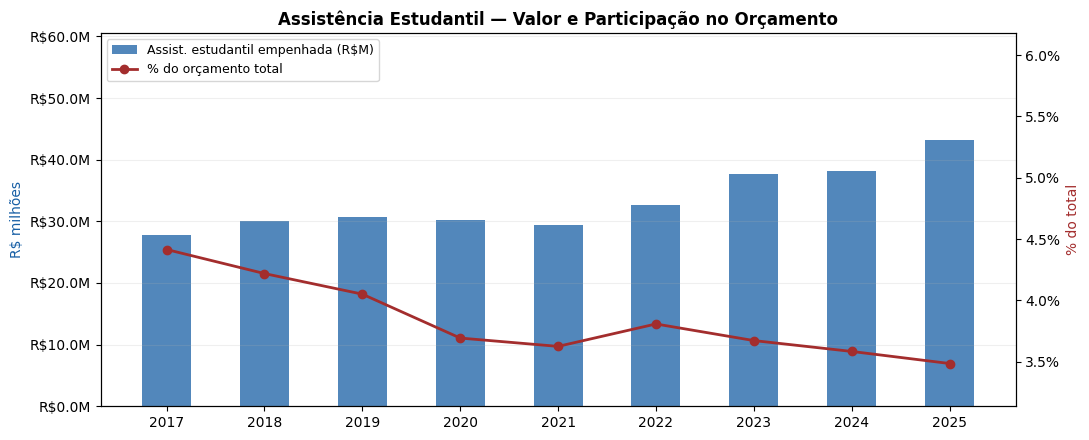

In [42]:
# FIGURA 3 — Assistência estudantil
fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax2 = ax1.twinx()

ax1.bar(assist["ano"], assist["assist_emp"]/1e6, color="#185FA5",
        alpha=0.75, width=0.5, label="Assist. estudantil empenhada (R$M)")
ax2.plot(assist["ano"], assist["pct_assist"], "o-", color="#A32D2D",
         lw=2, ms=6, label="% do orçamento total")

ax1.set_title("Assistência Estudantil — Valor e Participação no Orçamento", fontsize=12, fontweight="bold")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"R${x:.1f}M"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.1f}%"))
ax1.set_ylabel("R$ milhões", color="#185FA5")
ax2.set_ylabel("% do total", color="#A32D2D")
ax1.set_xticks(assist["ano"])
ax1.grid(alpha=0.2, axis="y")

ax1.set_ylim(0, assist["assist_emp"].max() / 1e6 * 1.4)
ax2.set_ylim(assist["pct_assist"].min() * 0.9, assist["pct_assist"].max() * 1.4)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, fontsize=9, loc="upper left")

plt.tight_layout()
plt.savefig("fig3_assistencia.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Análise por Campus

Agora desagregamos os dados por *campus* para identificar disparidades de execução, orçamento *per capita* e perfil de matrículas.

**Dados utilizados:**
- `portal_transparencia_clean.parquet` – orçamento por campus.
- `alunos_por_campus.csv` – matrículas ativas.
- `ifce-matriculas.csv` (original) – para detalhamento por nível de ensino.

In [38]:
df      = pd.read_parquet("portal_transparencia_clean.parquet")
alunos  = pd.read_csv("alunos_por_campus.csv")

# ranking execução por campus (últimos 4 anos: 2022–2025)
campus_exec = (df[df["ano"] >= 2022]
    .groupby("campus")
    .agg(empenhado=("valor_empenhado","sum"),
         pago=("valor_pago","sum"),
         n_linhas=("valor_empenhado","count"))
    .reset_index())
campus_exec = campus_exec[campus_exec["empenhado"] > 1e5]  # remove linhas residuais
campus_exec["tx_exec"] = campus_exec["pago"] / campus_exec["empenhado"] * 100
campus_exec = campus_exec.sort_values("tx_exec", ascending=True)

### Figura 4 – Ranking de execução por campus (2022–2025)

Para cada campus, calcula‑se a taxa de execução (`pago / empenhado`) no período 2022–2025, eliminando valores residuais (empenhado < R$ 100 mil).

Cores:
- **Verde** – execução ≥ 90%
- **Azul** – execução entre 80% e 90%
- **Vermelho** – execução < 80%

A linha vertical tracejada representa a média geral.

> **Nota:** O Polo de Inovação Fortaleza apresenta taxa > 100% (154,2%), possivelmente por pagamento de restos a pagar de exercícios anteriores. Por isso o eixo x é estendido para acomodar o valor real.

*Arquivo salvo: `fig4_ranking_campus.png`*

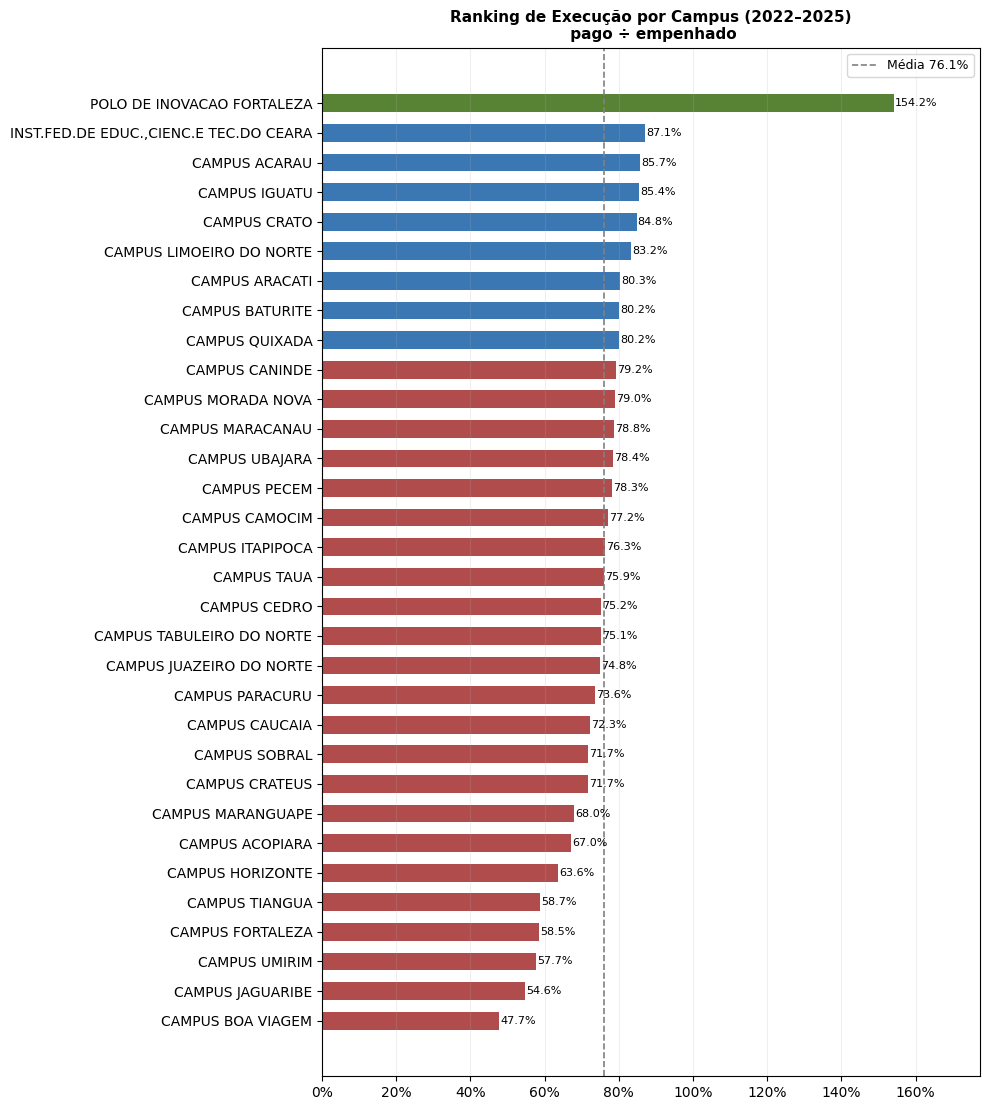

In [39]:
# FIGURA 4 — Ranking execução por campus
# define xlim dinâmico com margem para os rótulos (mínimo 115)
xlim_max = max(115, campus_exec["tx_exec"].max() * 1.15)

fig, ax = plt.subplots(figsize=(10, max(6, len(campus_exec)*0.35)))
cores = ["#3B6D11" if t>=90 else "#185FA5" if t>=80 else "#A32D2D"
         for t in campus_exec["tx_exec"]]
bars = ax.barh(campus_exec["campus"], campus_exec["tx_exec"],
               color=cores, alpha=0.85, height=0.6)
ax.axvline(campus_exec["tx_exec"].mean(), color="gray", lw=1.2, linestyle="--",
           label=f"Média {campus_exec['tx_exec'].mean():.1f}%")
for bar, v in zip(bars, campus_exec["tx_exec"]):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f"{v:.1f}%", va="center", fontsize=8)
ax.set_title("Ranking de Execução por Campus (2022–2025)\n pago ÷ empenhado",
             fontsize=11, fontweight="bold")
ax.set_xlim(0, xlim_max)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:.0f}%"))
ax.legend(fontsize=9); ax.grid(alpha=0.2, axis="x")
plt.tight_layout()
plt.savefig("fig4_ranking_campus.png", dpi=150, bbox_inches="tight")
plt.show()

### Figura 5 – Orçamento *per capita* por campus (ano mais recente)

Relaciona o total empenhado no último ano disponível com o número de alunos ativos de cada campus.

> **Atenção:** Campus com menos de 100 alunos ativos são excluídos desta análise para evitar distorções estatísticas causadas por denominadores muito pequenos. Os campi excluídos podem ser verificados confrontando a lista com `alunos_por_campus.csv`.

Cada barra exibe o valor em R$ mil por aluno, seguido pelo total de alunos entre parênteses.

*Arquivo salvo: `fig5_percapita.png`*

Campus excluídos (< 100 alunos): ['CAMPUS MARANGUAPE']


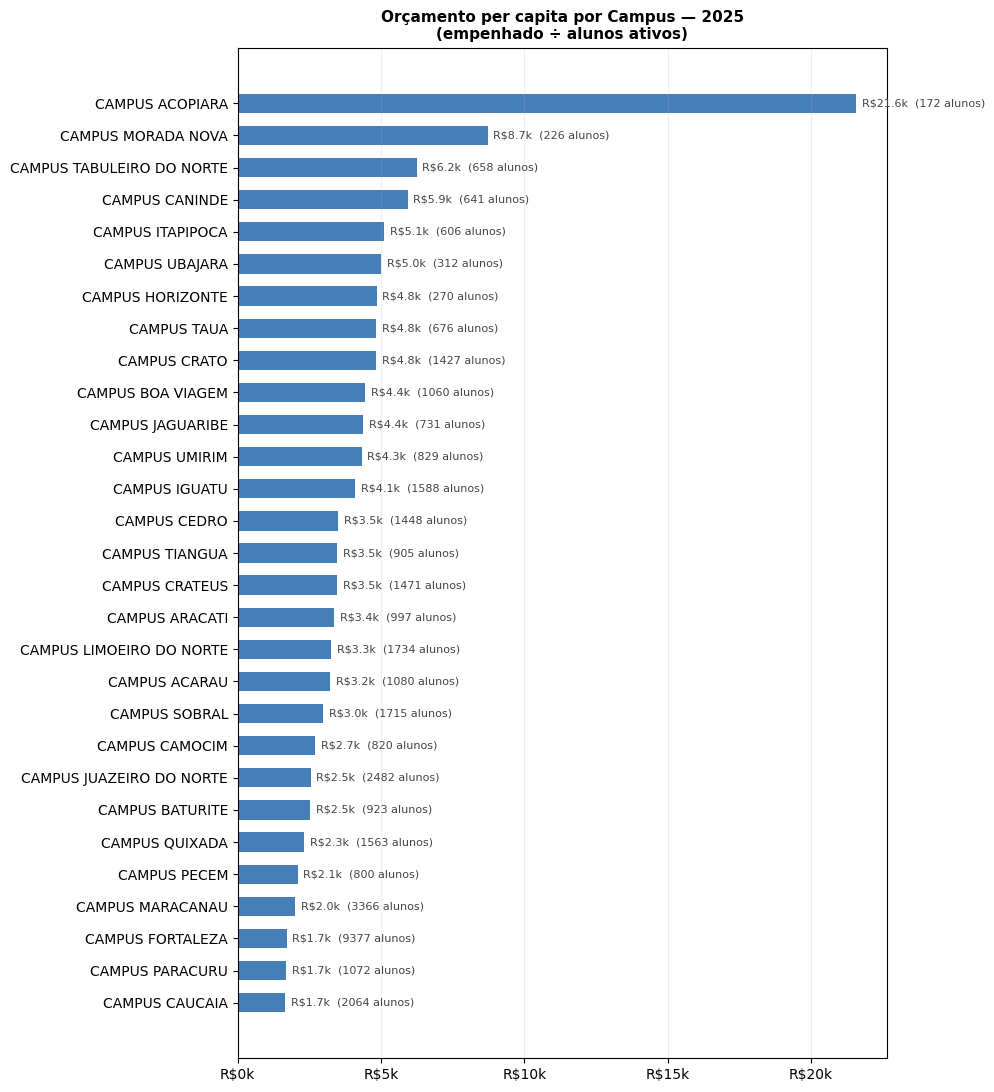

In [40]:
# FIGURA 5 — Per capita (orçamento ÷ alunos)
ano_recente = df["ano"].max()
orc_recente = (df[df["ano"] == ano_recente]
    .groupby("campus")["valor_empenhado"].sum()
    .reset_index()
    .rename(columns={"valor_empenhado": "orcamento"}))

percapita = orc_recente.merge(alunos, on="campus", how="inner")
percapita["per_capita"] = percapita["orcamento"] / percapita["total_alunos"]

# informa quais campus foram excluídos pelo filtro de tamanho
excluidos = percapita[percapita["total_alunos"] < 100]["campus"].tolist()
if excluidos:
    print(f"Campus excluídos (< 100 alunos): {excluidos}")

percapita = percapita[percapita["total_alunos"] >= 100]
percapita = percapita.sort_values("per_capita", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(percapita)*0.38)))
ax.barh(percapita["campus"], percapita["per_capita"]/1e3, color="#185FA5", alpha=0.8, height=0.6)
for i, (_, row) in enumerate(percapita.iterrows()):
    ax.text(row["per_capita"]/1e3 + 0.2, i,
            f"R${row['per_capita']/1e3:.1f}k  ({int(row['total_alunos'])} alunos)",
            va="center", fontsize=8, color="#444")
ax.set_title(f"Orçamento per capita por Campus — {ano_recente}\n(empenhado ÷ alunos ativos)",
             fontsize=11, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"R${x:.0f}k"))
ax.grid(alpha=0.2, axis="x")
plt.tight_layout()
plt.savefig("fig5_percapita.png", dpi=150, bbox_inches="tight")
plt.show()

### Figura 6 – Distribuição de matrículas ativas por campus e nível de ensino

Utilizando a base de matrículas original, filtra‑se apenas os alunos com situação `"Matriculado"` ou `"Matriculado(a)"`.  
As barras horizontais empilhadas mostram, para cada campus, a quantidade de alunos por nível de ensino.

A paleta de cores cobre todos os níveis presentes na base:
- **Técnico** (azul)
- **Graduação** (verde)
- **Pós-graduação** (laranja)
- **Ensino Médio** (roxo)
- **Extensão** (vinho)
- **Básico**, **Pós-técnico** e demais (cinza)

A ordenação é decrescente pelo total de alunos, facilitando a comparação do porte de cada campus.

*Arquivo salvo: `fig6_matriculas.png`*

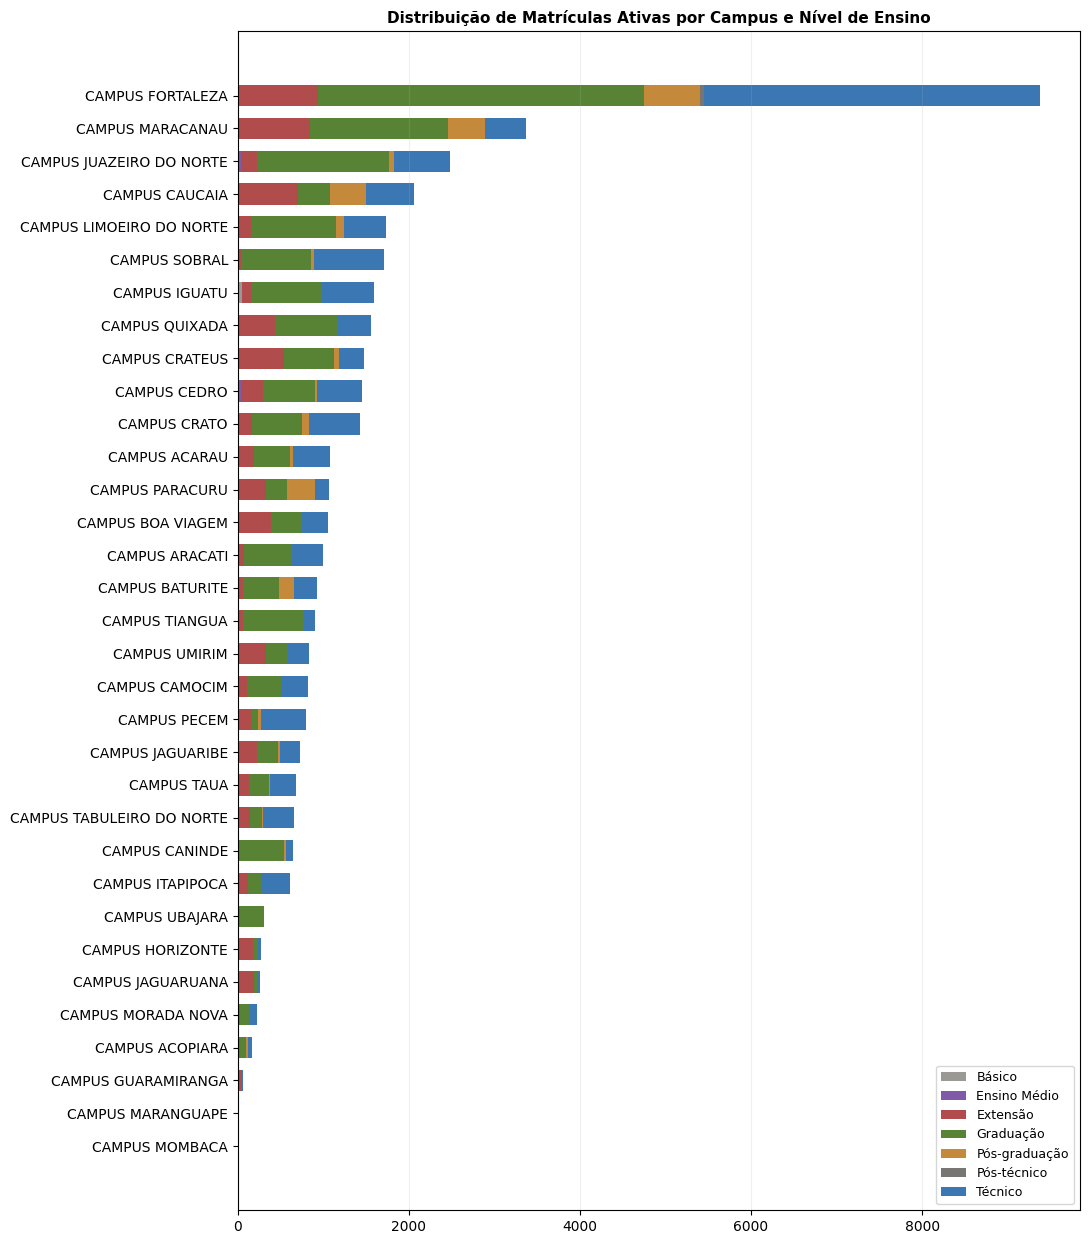

In [41]:
# FIGURA 6 — Distribuição de matrículas por campus e nível
df_mat2 = pd.read_csv("ifce-matriculas.csv", sep="\t")
df_mat2.columns = df_mat2.columns.str.strip().str.lower()
df_mat2["campus"] = (df_mat2["desc_instituicao"]
    .str.upper()
    .str.replace("IFCE - ", "", regex=False)
    .str.strip()
    .apply(remover_acentos))

ativos = df_mat2[df_mat2["sit_matricula"].isin(["Matriculado", "Matriculado(a)"])].copy()

pivot = (ativos.groupby(["campus", "nivel_ensino"])
    .size().unstack(fill_value=0))
pivot["total"] = pivot.sum(axis=1)
pivot = pivot.sort_values("total", ascending=True).drop(columns="total")

# paleta expandida para cobrir todos os níveis reais da base
cores_nivel = {
    "Técnico":        "#185FA5",
    "Graduação":      "#3B6D11",
    "Pós-graduação":  "#BA7517",
    "Ensino Médio":   "#6A3D9A",
    "Extensão":       "#A32D2D",
    "Básico":         "#888780",
    "Pós-técnico":    "#5F5E5A",
}

fig, ax = plt.subplots(figsize=(11, max(7, len(pivot)*0.38)))
bottom = pd.Series(0, index=pivot.index)
for nivel in pivot.columns:
    cor = cores_nivel.get(nivel, "#AAAAAA")
    ax.barh(pivot.index, pivot[nivel], left=bottom, color=cor,
            label=nivel, alpha=0.85, height=0.65)
    bottom += pivot[nivel]

ax.set_title("Distribuição de Matrículas Ativas por Campus e Nível de Ensino",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.2, axis="x")
plt.tight_layout()
plt.savefig("fig6_matriculas.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusão

Este notebook fornece uma visão panorâmica da execução orçamentária do IFCE, integrando dados de matrículas e ajustando valores pela inflação.  
As visualizações destacam:

- **Crescimento real do orçamento**: apesar da inflação acumulada (~53% entre 2017 e 2025), o orçamento cresceu em termos reais, indicando expansão efetiva da instituição.
- **Alta taxa de execução**: acima de 83% em todos os anos, com média de 86,8%, sinalizando boa capacidade de absorção dos recursos.
- **Predominância dos gastos com pessoal**: o grupo "Pessoal e Encargos Sociais" representa consistentemente mais de 70% do total pago.
- **Assistência estudantil em tensão**: embora os valores absolutos tenham crescido, a participação relativa da assistência estudantil no orçamento total caiu de ~4,4% em 2017–2018 para ~3,5% em 2025 — evidenciando que o crescimento orçamentário foi puxado principalmente por outras rubricas.
- **Heterogeneidade entre campi**: diferenças significativas tanto na taxa de execução (de ~48% a ~154%) quanto no orçamento *per capita* (de ~R$ 1,7k a ~R$ 22k por aluno).

Os arquivos gerados (`*.parquet`, `*.csv`, `*.png`) podem ser utilizados em relatórios ou análises complementares.